In [1]:
#download the data from kaggle
from pathlib import Path
path = Path('us-patent-phrase-to-phrase-matching')
if not path.exists():
    import zipfile,kaggle
    kaggle.api.competition_download_cli(str(path))
    zipfile.ZipFile(f'{path}.zip').extractall(path)

100%|█████████████████████████████████████████████████████████████████| 682k/682k [00:00<00:00, 612MB/s]

In [2]:
import pandas as pd

In [3]:
#creates dataframe from a csv, which is basically a table
df = pd.read_csv(path/'train.csv')

In [4]:
df

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00
...,...,...,...,...,...
36468,8e1386cbefd7f245,wood article,wooden article,B44,1.00
36469,42d9e032d1cd3242,wood article,wooden box,B44,0.50
36470,208654ccb9e14fa3,wood article,wooden handle,B44,0.50
36471,756ec035e694722b,wood article,wooden material,B44,0.75


In [5]:
#we can look at the description of the dataset:
#this usually only displas numeric types. include=object shows us objects like strings
df.describe(include='object')

,id,anchor,target,context
count,36473,36473,36473,36473
unique,36473,733,29340,106
top,8d135da0b55b8c88,component composite coating,composition,H01
freq,1,152,24,2186


In [6]:
#add data representation context:
df['input'] = 'TEXT1: ' + df.context + '; TEXT2: ' + df.target + '; ANC1: ' + df.anchor

In [7]:
df.input.head()

0    TEXT1: A47; TEXT2: abatement of pollution; ANC...
1    TEXT1: A47; TEXT2: act of abating; ANC1: abate...
2    TEXT1: A47; TEXT2: active catalyst; ANC1: abat...
3    TEXT1: A47; TEXT2: eliminating process; ANC1: ...
4    TEXT1: A47; TEXT2: forest region; ANC1: abatement
Name: input, dtype: object

In [8]:
#Dataset is what Transformers use for storage, created from a dataframe here
from datasets import Dataset,DatasetDict

ds = Dataset.from_pandas(df)

In [9]:
ds

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'score', 'input'],
    num_rows: 36473
})

In [10]:
# choose our model
model_nm = 'microsoft/deberta-v3-small'

In [11]:
#get the tokenizer from the model and instantiate
from transformers import AutoModelForSequenceClassification,AutoTokenizer
tokz = AutoTokenizer.from_pretrained(model_nm)

/home/puhi/miniforge3/envs/fastai/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [12]:
tokz.tokenize("A platypus is an ornithorhynchus anatinus.")

['▁A',
 '▁platypus',
 '▁is',
 '▁an',
 '▁or',
 'ni',
 'tho',
 'rhynch',
 'us',
 '▁an',
 'at',
 'inus',
 '.']

In [13]:
#make a function that does it
def tok_func(x): return tokz(x["input"])

In [14]:
#map is good here because it parallelizes (with batched)
tok_ds = ds.map(tok_func, batched=True)

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

In [15]:
#this adds a new item to the set called input_ids
row = tok_ds[0]
row['input'], row['input_ids']

('TEXT1: A47; TEXT2: abatement of pollution; ANC1: abatement',
 [1,
  54453,
  435,
  294,
  336,
  5753,
  346,
  54453,
  445,
  294,
  47284,
  265,
  6435,
  346,
  23702,
  435,
  294,
  47284,
  2])

In [16]:
#those are the numericalized versions of the words
# you can check what number certain words are:
tokz.vocab['▁of']

265

In [17]:
#expects 'labels', so update to 'score'
tok_ds = tok_ds.rename_columns({'score':'labels'})

In [18]:
eval_df = pd.read_csv(path/'test.csv')
eval_df.describe()

,id,anchor,target,context
count,36,36,36,36
unique,36,34,36,29
top,4112d61851461f60,hybrid bearing,inorganic photoconductor drum,G02
freq,1,2,1,3


In [19]:
dds = tok_ds.train_test_split(0.25, seed=42)
dds

DatasetDict({
    train: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27354
    })
    test: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9119
    })
})

In [20]:
eval_df['input'] = 'TEXT1: ' + eval_df.context + '; TEXT2: ' + eval_df.target + '; ANC1: ' + eval_df.anchor
eval_ds = Dataset.from_pandas(eval_df).map(tok_func, batched=True)

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

In [21]:
#Talk about Pearson for a minute
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
housing = housing['data'].join(housing['target']).sample(1000, random_state=52)
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
7506,3.0550,37.0,5.152778,1.048611,729.0,5.062500,33.92,-118.28,1.054
4720,3.0862,35.0,4.697897,1.055449,1159.0,2.216061,34.05,-118.37,3.453
12888,2.5556,24.0,4.864905,1.129222,1631.0,2.395007,38.66,-121.35,1.057
13344,3.0057,32.0,4.212687,0.936567,1378.0,5.141791,34.05,-117.64,0.969
7173,1.9083,42.0,3.888554,1.039157,1535.0,4.623494,34.05,-118.19,1.192


In [22]:
#np.corrcoef gives correlation coefficient for each row compared to each other row:

In [23]:
import numpy as np, matplotlib.pyplot as plt
np.set_printoptions(precision=2, suppress=True)

np.corrcoef(housing, rowvar=False)

array([[ 1.  , -0.12,  0.43, -0.08,  0.01, -0.07, -0.12,  0.04,  0.68],
       [-0.12,  1.  , -0.17, -0.06, -0.31,  0.  ,  0.03, -0.13,  0.12],
       [ 0.43, -0.17,  1.  ,  0.76, -0.09, -0.07,  0.12, -0.03,  0.21],
       [-0.08, -0.06,  0.76,  1.  , -0.08, -0.07,  0.09,  0.  , -0.04],
       [ 0.01, -0.31, -0.09, -0.08,  1.  ,  0.16, -0.15,  0.13,  0.  ],
       [-0.07,  0.  , -0.07, -0.07,  0.16,  1.  , -0.16,  0.17, -0.27],
       [-0.12,  0.03,  0.12,  0.09, -0.15, -0.16,  1.  , -0.93, -0.16],
       [ 0.04, -0.13, -0.03,  0.  ,  0.13,  0.17, -0.93,  1.  , -0.03],
       [ 0.68,  0.12,  0.21, -0.04,  0.  , -0.27, -0.16, -0.03,  1.  ]])

In [24]:
#-1 is direct inverse, +1 is direct
#1s down the middle because comparing to self
#overkill when we want a single coefficient, so define our own quickie:
def corr(x,y): return np.corrcoef(x,y)[0][1]

corr(housing.MedInc, housing.MedHouseVal)

np.float64(0.6760250732906005)

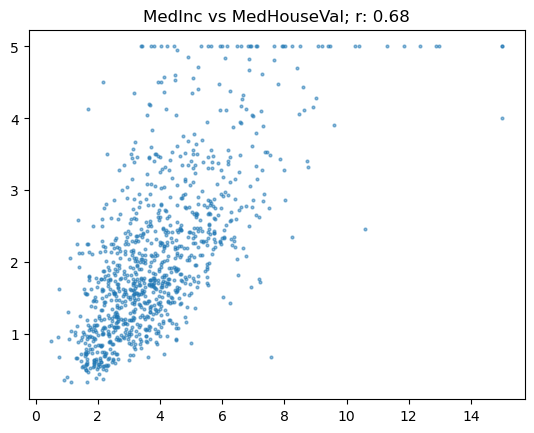

In [25]:
#let's look and see how correlated that really is:
def show_corr(df, a, b):
    x,y = df[a],df[b]
    plt.scatter(x,y, alpha=0.5, s=4)
    plt.title(f'{a} vs {b}; r: {corr(x, y):.2f}')

show_corr(housing, 'MedInc', 'MedHouseVal')

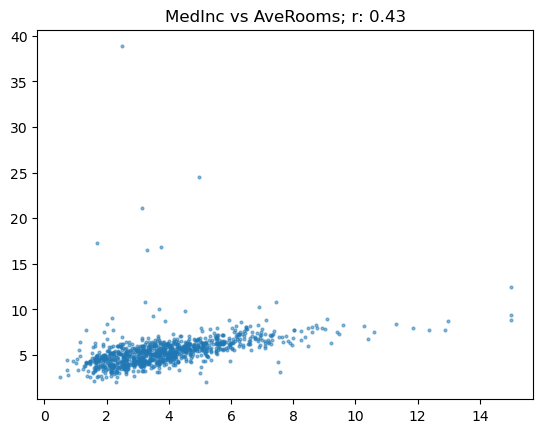

In [26]:
#.68 pretty correlated, another:
show_corr(housing, 'MedInc', 'AveRooms')

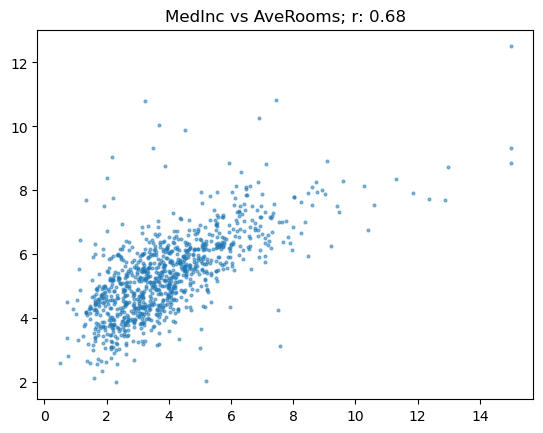

In [27]:
#looks similar, but worse score. Why? outliers.
#r is very sensitive to outliers, remove them:
subset = housing[housing.AveRooms<15]
show_corr(subset, 'MedInc', 'AveRooms')

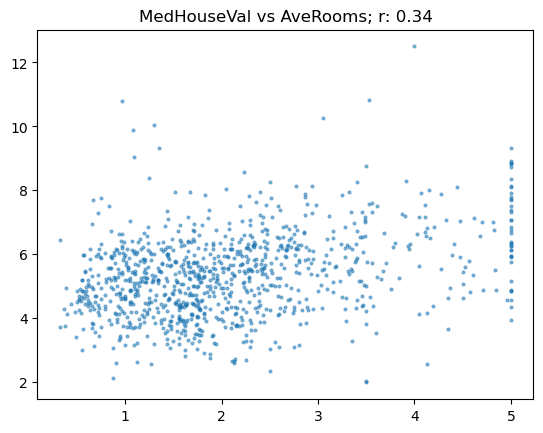

In [28]:
show_corr(subset, 'MedHouseVal', 'AveRooms')

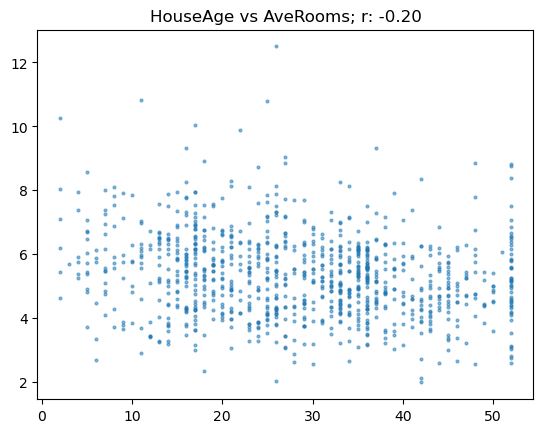

In [29]:
show_corr(subset, 'HouseAge', 'AveRooms')

In [30]:
#Transformers expects metrics to be dict, so it knows what label to use.
#let's make a new function for that

def corr_d(eval_pred): return {'pearson': corr(*eval_pred)}

In [31]:
#Training time, import, batchsize, and epoch
from transformers import TrainingArguments,Trainer

In [32]:
bs = 128
epochs = 4

In [33]:
#learning rate is important, fastai has a tool to find, but Transformers doesn't
#try to get as big as possible without training failing.
lr = 8e-5

In [34]:
#Transformers uses TrainingArguments to set up arguments. These settings are generally good.
# just change the ones we listed above.
args = TrainingArguments('outputs', learning_rate=lr, warmup_ratio=0.1, lr_scheduler_type='cosine', fp16=True,
    eval_strategy="epoch", per_device_train_batch_size=bs, per_device_eval_batch_size=bs*2,
    num_train_epochs=epochs, weight_decay=0.01, report_to='none')

In [35]:
#create model
model = AutoModelForSequenceClassification.from_pretrained(model_nm, num_labels=1)
trainer = Trainer(model, args, train_dataset=dds['train'], eval_dataset=dds['test'],
                  tokenizer=tokz, compute_metrics=corr_d)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_661/3678270128.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model, args, train_dataset=dds['train'], eval_dataset=dds['test'],


In [36]:
trainer.train();

Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.030713,0.793928
2,No log,0.022984,0.818937
3,0.034600,0.021937,0.829974
4,0.034600,0.022546,0.831170


In [37]:
#predicting on the test set:
preds = trainer.predict(eval_ds).predictions.astype(float)
preds

array([[ 0.61],
       [ 0.74],
       [ 0.59],
       [ 0.31],
       [-0.03],
       [ 0.51],
       [ 0.52],
       [-0.03],
       [ 0.2 ],
       [ 1.1 ],
       [ 0.31],
       [ 0.25],
       [ 0.75],
       [ 0.86],
       [ 0.73],
       [ 0.34],
       [ 0.28],
       [-0.01],
       [ 0.57],
       [ 0.29],
       [ 0.42],
       [ 0.26],
       [ 0.13],
       [ 0.23],
       [ 0.53],
       [-0.03],
       [-0.03],
       [-0.01],
       [-0.05],
       [ 0.62],
       [ 0.42],
       [ 0.01],
       [ 0.69],
       [ 0.52],
       [ 0.41],
       [ 0.2 ]])

In [38]:
#<0 is no good
preds = np.clip(preds, 0, 1)

In [39]:
preds

array([[0.61],
       [0.74],
       [0.59],
       [0.31],
       [0.  ],
       [0.51],
       [0.52],
       [0.  ],
       [0.2 ],
       [1.  ],
       [0.31],
       [0.25],
       [0.75],
       [0.86],
       [0.73],
       [0.34],
       [0.28],
       [0.  ],
       [0.57],
       [0.29],
       [0.42],
       [0.26],
       [0.13],
       [0.23],
       [0.53],
       [0.  ],
       [0.  ],
       [0.  ],
       [0.  ],
       [0.62],
       [0.42],
       [0.01],
       [0.69],
       [0.52],
       [0.41],
       [0.2 ]])

In [42]:
import datasets


submission_df = pd.DataFrame({
    'id': eval_df['id'],
    'score': preds.flatten()  # Use .flatten() to convert the 2D array to a 1D array
})
submission_df.to_csv('submission.csv', index=False)

In [43]:
submission_df

,id,score
0,4112d61851461f60,0.612793
1,09e418c93a776564,0.738281
2,36baf228038e314b,0.593750
3,1f37ead645e7f0c8,0.307617
4,71a5b6ad068d531f,0.000000
5,474c874d0c07bd21,0.512695
6,442c114ed5c4e3c9,0.521484
7,b8ae62ea5e1d8bdb,0.000000
8,faaddaf8fcba8a3f,0.201294
9,ae0262c02566d2ce,1.000000
